# **Logistic Regression**

# 1) Linear Regression

**Linear Regression** is a supervised learning algorithm used to predict a **continuous numeric value** (like price, salary, temperature).  
It assumes a linear relationship between input features and the output:

$$
\hat{y} = mx + b
$$

**Why we use it:** because it is simple, fast, interpretable, and works well when the relationship between inputs and output is approximately linear.

---

# 2) Logistic Regression

Even though it is called **Logistic Regression**, it is mainly used for **classification**, especially **binary classification** (0/1).

**Reason:**  
- Logistic regression computes a linear score $$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots$$,
- but then it passes that score through the **sigmoid function** to produce a **probability** between 0 and 1,
- and finally uses a threshold (like 0.5) to assign a **class label**.

So the “regression” part is only about producing a score; the final output is a **class**.

---

# 3) Requirement / Condition for Logistic Regression

A key requirement (basic assumption) for logistic regression is that the data should be **linearly separable (or approximately linearly separable)**.

**Linearly separable** means:  
We can draw a straight line (in 2D) that separates the two classes:

- Class 0 on one side  
- Class 1 on the other side  

---

# 4) Geometric Intuition (Decision Boundary)

For 2 features $$x_1$$ and $$x_2$$, the decision boundary is:

$$
A x_1 + B x_2 + C = 0
$$

- $$A, B$$ are weights (they control the slope / direction of the line)
- $$C$$ is the **intercept** (it shifts the line up/down or left/right)

This line splits the plane into **two regions**.

---

# 5) Perceptron Trick (Algorithm intuition with 100 loops)

We are talking about the **Perceptron trick**:

We run a loop (say **100 times**):
1. Pick a **random point**
2. Check if it is in the **correct region**
3. If correct → do **nothing** (no change in $$A,B$$)
4. If incorrect → update $$A,B$$ (weights) so the line moves

**Internal intuition:**  
- A misclassified point “pulls” the boundary toward itself (the boundary shifts to fix it).
- The line reacts to mistakes by adjusting weights.
- If the point is pushing the line towards itself, the line is pushing towards the point (boundary moves toward that point).

---

# 6) How to label regions (positive region vs negative region)

We compute:

$$
f(x) = a x_1 + b x_2 + c
$$

- If $$f(x) > 0$$ → point lies in the **positive region**
- If $$f(x) < 0$$ → point lies in the **negative region**

So the **sign** tells which side of the line the point is on.

---

# 7) Weight update rule idea + Learning Rate

We update weights like this (basic idea):

$$
\text{new coefficient} = \text{old coefficient} - (\text{learning rate}) \times (\text{coordinates})
$$

### What is Learning Rate (easy wording)?
**Learning rate** is a small number (like 0.1, 0.01) that controls **how big the update step is**.  
- Small learning rate → change is **slow and gradual** (more stable)
- Large learning rate → change is **fast but can overshoot**

So learning rate decides how gently or aggressively we move the line, and the change is usually **very gradual**.

We often write learning rate as $$\eta$$.

---

# 8) Example dataset (CGPA, IQ → Job Placement)

We have 2 input features and 1 output:

| CGPA ($$x_1$$) | IQ ($$x_2$$) | Job Placement ($$y$$) |
|--------------:|------------:|----------------------:|
| 8.0           | 110         | 1                     |
| 6.0           | 90          | 0                     |
| 7.5           | 105         | 1                     |
| 5.5           | 85          | 0                     |

---

# 9) From $$A x_1 + B x_2 + C = 0$$ to W-form

We can write:

$$
A x_1 + B x_2 + C = 0
$$

Replace:
- $$w_0 = C$$
- $$w_1 = A$$
- $$w_2 = B$$

Then:

$$
w_0 + w_1 x_1 + w_2 x_2 = 0
$$

General form:

$$
\sum_{i=0}^{2} w_i x_i = 0
$$

(Here $$x_0 = 1$$ so that $$w_0$$ acts as intercept.)

---

# 10) How to predict class using the linear boundary

Compute:

$$
s = \sum_{i=0}^{2} w_i x_i
$$

Prediction rule:

- If $$s \ge 0$$ → Class = 1  
- If $$s < 0$$ → Class = 0  

---

# 11) What is an Epoch?

The loop we use above is called an **epoch**.

**Epoch definition:**  
An **epoch** means **one complete pass** over the training data (or one full cycle of training steps).  
If we run multiple epochs, we repeatedly adjust weights again and again.

---

# 12) Perceptron update rules (two cases)

Let the score be:

$$
s = \sum_{i=0}^{2} w_i x_i
$$

### Case 1 (Negative class misclassified)
If $$x_i$$ belongs to **negative class** and $$s \ge 0$$ (wrong side):

$$
w_{\text{new}} = w_{\text{old}} - \eta x_i
$$

### Case 2 (Positive class misclassified)
If $$x_i$$ belongs to **positive class** and $$s < 0$$ (wrong side):

$$
w_{\text{new}} = w_{\text{old}} + \eta x_i
$$

where $$\eta$$ is learning rate.

---

# 13) More generalized update form

A more general update:

$$
w_{\text{new}} = w_{\text{old}} + \eta (y - \hat{y}) x
$$

- $$y$$ = true label  
- $$\hat{y}$$ = predicted label  
- $$x$$ = feature vector  

---

# 14) Disadvantage of Perceptron (Big flaw)

**Perceptron flaw:**  
Only **misclassified points** affect weight updates.  
Correctly classified points have **no role** in improving the boundary further.

So the boundary does not get refined using correct points.

---

# 15) Fixing the Perceptron flaw (idea)

We want:
- Misclassified points should pull the line,  
- AND correctly classified points should also contribute (push/refine the line slightly).

To do this, we replace the hard step function with a smooth function.

---

# 16) Step Function and Activation Function

### Activation Function (definition)
An **activation function** converts the model’s score into an output signal (class/probability).

### Step Function (definition)
The **step function** outputs only two values:

$$
\hat{y} =
\begin{cases}
1, & s \ge 0 \\
0, & s < 0
\end{cases}
$$

This is “hard” and not smooth (no gradual learning).

---

# 17) Moving to Sigmoid (Logistic Regression)

Instead of step, Logistic Regression uses **sigmoid**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where:

$$
z = w^T x + b
$$

### Importance of sigmoid
- It converts any real number into a **probability**
- Output is always between **0 and 1**

$$
0 < \sigma(z) < 1
$$

So logistic regression is basically:
**Perceptron trick + Sigmoid function**.

---

# 18) Loss function vs Cost function

### Loss function
Loss is the error for **one training example**.

### Cost function
Cost is the average (or total) loss over **the whole dataset**.

So:
- Loss → single example  
- Cost → overall dataset  

---

# 19) Cross-Entropy Loss (used in Logistic Regression)

For binary classification:

$$
L(y,\hat{p}) = -\left[y\log(\hat{p}) + (1-y)\log(1-\hat{p})\right]
$$

where:
- $$y \in \{0,1\}$$  
- $$\hat{p} = \sigma(z)$$ is predicted probability  

---

# 20) Why Cross-Entropy is preferred over MSE

**Mean Squared Error (MSE)** is better for regression.  
In classification with sigmoid:

- MSE can make learning **slow** because gradients can become very small  
- Cross-entropy produces **stronger, more useful gradients**  
- Cross-entropy matches probability modeling (maximum likelihood)  

So cross-entropy is more stable and faster for logistic regression training.

---

# 21) Small weight-update example (5 loops only, show new weights each loop)

We will use a simple small dataset with 2 features:

| CGPA ($$x_1$$) | IQ ($$x_2$$) | $$y$$ |
|--------------:|------------:|-----:|
| 8             | 110         | 1    |
| 6             | 90          | 0    |

We will use:
- Add bias term $$x_0 = 1$$  
- Learning rate $$\eta = 0.01$$  
- Initial weights: $$w_0=0,\; w_1=0,\; w_2=0$$  

### Logistic prediction
$$
z = w_0 + w_1 x_1 + w_2 x_2
$$

$$
\hat{p} = \sigma(z)
$$

Update rule:
$$
w_{\text{new}} = w_{\text{old}} + \eta (y - \hat{p}) x
$$

---

## Loop 1 (use point $$x=[1,8,110],\; y=1$$)
$$
z = 0
$$
$$
\hat{p} = \sigma(0)=0.5
$$
$$
y-\hat{p} = 0.5
$$

Update:
$$
w_0 = 0 + 0.01(0.5)(1)=0.005
$$
$$
w_1 = 0 + 0.01(0.5)(8)=0.04
$$
$$
w_2 = 0 + 0.01(0.5)(110)=0.55
$$

Weights after loop 1:
$$
[w_0,w_1,w_2] = [0.005,\; 0.04,\; 0.55]
$$

---

## Loop 2 (use point $$x=[1,6,90],\; y=0$$)
$$
z = 0.005 + 0.04(6) + 0.55(90)
$$
$$
z = 0.005 + 0.24 + 49.5 = 49.745
$$

$$
\hat{p} = \sigma(49.745) \approx 1
$$
$$
y-\hat{p} \approx -1
$$

Update (approx):
$$
w_0 \approx 0.005 + 0.01(-1)(1)= -0.005
$$
$$
w_1 \approx 0.04 + 0.01(-1)(6)= -0.02
$$
$$
w_2 \approx 0.55 + 0.01(-1)(90)= -0.35
$$

Weights after loop 2:
$$
[w_0,w_1,w_2] \approx [-0.005,\; -0.02,\; -0.35]
$$

---

## Loop 3 (use point $$x=[1,8,110],\; y=1$$)
$$
z = -0.005 + (-0.02)(8) + (-0.35)(110)
$$
$$
z = -0.005 -0.16 -38.5 = -38.665
$$

$$
\hat{p} = \sigma(-38.665) \approx 0
$$
$$
y-\hat{p} \approx 1
$$

Update (approx):
$$
w_0 \approx -0.005 + 0.01(1)(1)= 0.005
$$
$$
w_1 \approx -0.02 + 0.01(1)(8)= 0.06
$$
$$
w_2 \approx -0.35 + 0.01(1)(110)= 0.75
$$

Weights after loop 3:
$$
[w_0,w_1,w_2] \approx [0.005,\; 0.06,\; 0.75]
$$

---

## Loop 4 (use point $$x=[1,6,90],\; y=0$$)
$$
z = 0.005 + 0.06(6) + 0.75(90)
$$
$$
z = 0.005 + 0.36 + 67.5 = 67.865
$$

$$
\hat{p} = \sigma(67.865) \approx 1
$$
$$
y-\hat{p} \approx -1
$$

Update (approx):
$$
w_0 \approx 0.005 - 0.01 = -0.005
$$
$$
w_1 \approx 0.06 - 0.06 = 0
$$
$$
w_2 \approx 0.75 - 0.90 = -0.15
$$

Weights after loop 4:
$$
[w_0,w_1,w_2] \approx [-0.005,\; 0,\; -0.15]
$$

---

## Loop 5 (use point $$x=[1,8,110],\; y=1$$)
$$
z = -0.005 + 0(8) + (-0.15)(110)
$$
$$
z = -0.005 - 16.5 = -16.505
$$

$$
\hat{p} = \sigma(-16.505) \approx 0
$$
$$
y-\hat{p} \approx 1
$$

Update (approx):
$$
w_0 \approx -0.005 + 0.01 = 0.005
$$
$$
w_1 \approx 0 + 0.01(8)= 0.08
$$
$$
w_2 \approx -0.15 + 0.01(110)= 0.95
$$

Weights after loop 5:
$$
[w_0,w_1,w_2] \approx [0.005,\; 0.08,\; 0.95]
$$

**Note:** In real training, we usually scale features (IQ is large), so updates become more stable and not extreme.

---

# 22) Advantages, Disadvantages, and Uses of Logistic Regression

## Advantages
- Works very well when data is (approximately) **linearly separable**
- Outputs **probabilities**
- Simple, fast, and interpretable
- Works well on small-to-medium datasets

## Disadvantages
- Struggles with **non-linear boundaries** unless we add feature transformations
- Sensitive to **outliers**
- Needs feature scaling sometimes for stable learning

## Where we use Logistic Regression
- Spam detection (spam / not spam)
- Disease prediction (yes / no)
- Customer churn (leave / stay)
- Credit default (default / no default)
- Any binary classification problem where relationship is roughly linear

---


https://www.desmos.com/calculator

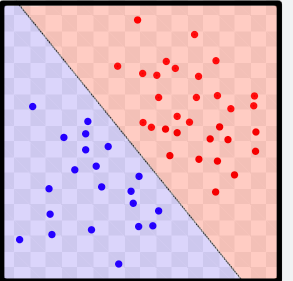

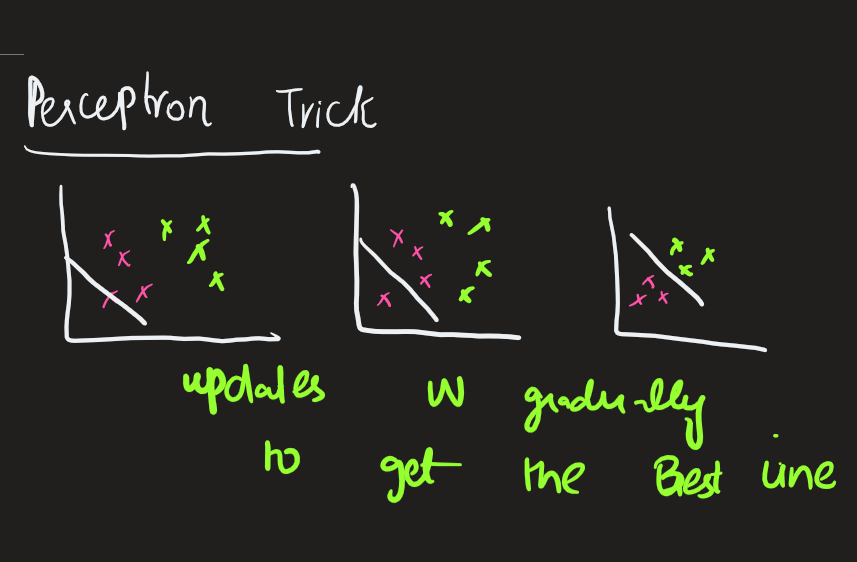

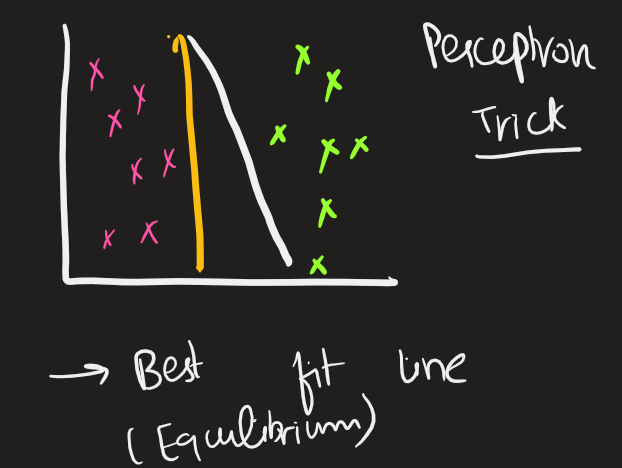

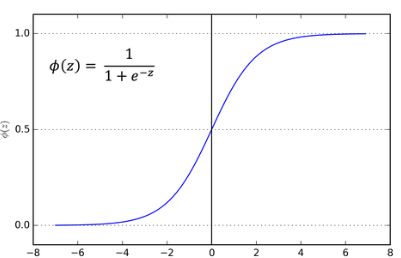

## Comparison: Traditional Error vs Cross-Entropy (Binary Classification)

| Aspect | Traditional Error (Actual − Predicted) | Cross-Entropy Loss (Logistic Regression) |
|---|---|---|
| Formula | $e = y - \hat{y}$ | $L(y,\hat{p}) = -\left[y\log(\hat{p}) + (1-y)\log(1-\hat{p})\right]$ |
| Output type | Can be negative, zero, or positive | Always $\ge 0$ |
| What it measures | Raw difference between label and prediction | How “wrong” the predicted probability is |
| Works best for | Regression or perceptron-style updates | Probability-based classification |
| Uses probability? | No (usually uses hard class $\hat{y}\in\{0,1\}$) | Yes (uses $\hat{p}\in(0,1)$) |
| Penalizes confident wrong predictions | Not strongly (depends on setup) | Yes, penalizes very heavily |
| Differentiable (smooth)? | Often not (if $\hat{y}$ comes from step) | Yes (smooth, good for gradient descent) |
| Example (if $y=1$) | If $\hat{y}=0$, $e=1$ | If $\hat{p}=0.01$, $L\approx -\log(0.01)$  |
| Main advantage | Very simple, easy intuition | Stable training + better gradients for classification |


## Comparison: Simple Linear Regression vs Logistic Regression

| Aspect | Simple Linear Regression | Logistic Regression |
|---|---|---|
| Task | Regression (predict a number) | Classification (predict a class / probability) |
| Output | Continuous value $\hat{y}\in(-\infty,\infty)$ | Probability $\hat{p}\in(0,1)$ and class $\hat{y}\in\{0,1\}$ |
| Model equation | $\hat{y} = w_0 + w_1 x_1 + \dots + w_n x_n$ | $z = w_0 + w_1 x_1 + \dots + w_n x_n$ then $\hat{p}=\sigma(z)$ |
| Activation | None (direct output) | Sigmoid: $\sigma(z)=\dfrac{1}{1+e^{-z}}$ |
| Decision boundary | Not used for classification | Uses boundary: $w_0+w_1x_1+\dots+w_nx_n=0$ |
| Loss function | Usually MSE: $J=\dfrac{1}{m}\sum_{i=1}^{m}(y^{(i)}-\hat{y}^{(i)})^2$ | Cross-entropy: $J=\dfrac{1}{m}\sum_{i=1}^{m}-\left[y^{(i)}\log(\hat{p}^{(i)})+(1-y^{(i)})\log(1-\hat{p}^{(i)})\right]$ |
| Best suited for | Predicting quantities (price, marks) | Binary outcomes (yes/no, spam/not spam) |
| Key assumption | Linear relationship between $x$ and $y$ | Classes are (approximately) linearly separable |
| Example use | House price prediction | Disease prediction, churn prediction |


In [ ]:
# ✅ Code Cell 1: Imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# ✅ Code Cell 2: Create a bigger dataset (30 rows): CGPA, IQ -> Placed (1/0)
# (Synthetic dataset for learning/demo)

data = {
    "CGPA": [
        5.0, 5.2, 5.5, 5.7, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4,
        6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4,
        7.5, 7.6, 7.7, 7.8, 8.0, 8.2, 8.3, 8.5, 8.7, 9.0
    ],
    "IQ": [
        78, 80, 82, 85, 87, 88, 90, 92, 93, 95,
        97, 98, 100, 101, 103, 104, 106, 108, 109, 111,
        112, 114, 116, 118, 120, 122, 124, 126, 128, 132
    ],
    "Placed": [
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)
df


,CGPA,IQ,Placed
0,5.0,78,0
1,5.2,80,0
2,5.5,82,0
3,5.7,85,0
4,5.9,87,0
5,6.0,88,0
6,6.1,90,0
7,6.2,92,0
8,6.3,93,0
9,6.4,95,0


In [ ]:
# ✅ Code Cell 3: Split into features (X) and target (y)
X = df[["CGPA", "IQ"]]
y = df["Placed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (22, 2)
Test size : (8, 2)


In [ ]:
# ✅ Code Cell 4: Train Logistic Regression model (scikit-learn)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained ✅")


Model trained ✅


In [ ]:
# ✅ Code Cell 5: Predictions + Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[4 0]
 [0 4]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [ ]:
# ✅ Code Cell 6: Predict on new students (examples)
new_students = pd.DataFrame({
    "CGPA": [6.4, 7.0, 7.8, 8.6],
    "IQ":   [95, 104, 118, 128]
})

pred_class = model.predict(new_students)
pred_prob = model.predict_proba(new_students)[:, 1]  # prob of class 1

result = new_students.copy()
result["Predicted_Placed"] = pred_class
result["Placement_Probability"] = pred_prob

result


,CGPA,IQ,Predicted_Placed,Placement_Probability
0,6.4,95,0,0.016556
1,7.0,104,1,0.747610
2,7.8,118,1,0.999891
3,8.6,128,1,1.000000


In [ ]:
# ✅ Code Cell 7: Show learned decision boundary parameters
# Decision boundary: w0 + w1*CGPA + w2*IQ = 0
print("Intercept (w0):", model.intercept_[0])
print("Weights  (w1,w2):", model.coef_[0])


Intercept (w0): -58.66279756156873
Weights  (w1,w2): [0.06327864 0.57024761]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


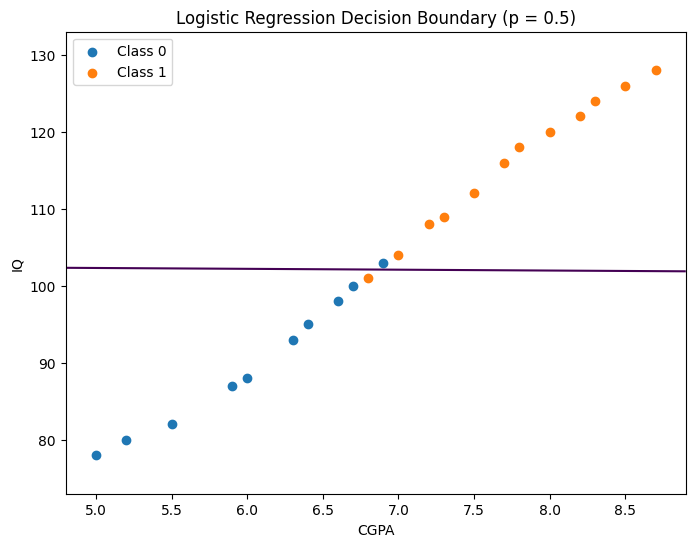

In [ ]:
# ✅ Decision Boundary Visualization (works with pandas DataFrame or numpy array)

import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays safely
Xtr = X_train.values if hasattr(X_train, "values") else X_train
ytr = y_train.values if hasattr(y_train, "values") else y_train

plt.figure(figsize=(8, 6))

# Plot points
plt.scatter(Xtr[ytr == 0][:, 0], Xtr[ytr == 0][:, 1], label="Class 0")
plt.scatter(Xtr[ytr == 1][:, 0], Xtr[ytr == 1][:, 1], label="Class 1")

# Mesh grid
x_min, x_max = Xtr[:, 0].min() - 0.2, Xtr[:, 0].max() + 0.2
y_min, y_max = Xtr[:, 1].min() - 5,  Xtr[:, 1].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

# Decision boundary (p = 0.5)
plt.contour(xx, yy, probs, levels=[0.5])

plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Logistic Regression Decision Boundary (p = 0.5)")
plt.legend()
plt.show()
